In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from scipy.stats import beta, multinomial, binom
from scipy.special import comb

In [3]:
data = np.array([5,2,6,4,4,6,3,4,2])

In [4]:
support_n = list(range(6,11))
support_n

[6, 7, 8, 9, 10]

In [5]:
def dis_n(x, p, support_n, size):
  probs = []
  for n in support_n:
    probs.append(float((1-p)**(x.shape[0]*n) * np.prod([comb(n, j, exact=True) for j in x])))
  probs = np.array(probs)
  probs = probs / np.sum(probs)
  return support_n[np.where(multinomial.rvs(n=1,p=probs, size=size)[0])[0][0]]

In [6]:
dis_n(data, 0.7, support_n, 10)

6

In [7]:
p_s = [0.5]
n_s = [7]
x_s = [2]


for i in range(1,5001):
  p_s.append(beta.rvs(1+data.sum(),1+data.shape[0] * n_s[-1] - data.sum(),size=1)[0])
  n_s.append(dis_n(data, p_s[-1], support_n, 1))

  x_s.append(binom.rvs(n=n_s[-1], p = p_s[-1]))

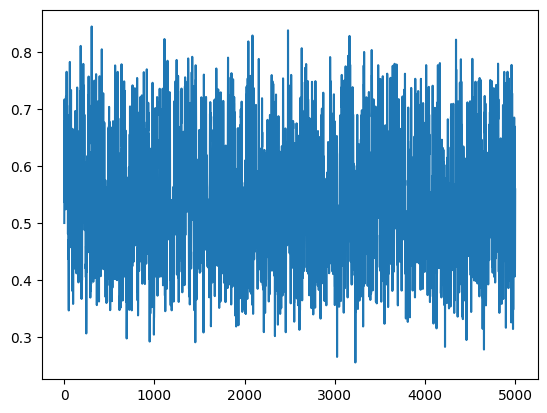

In [8]:
plt.plot(p_s)

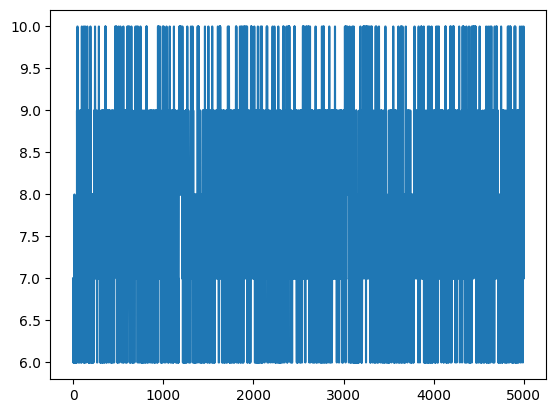

In [9]:
plt.plot(n_s)

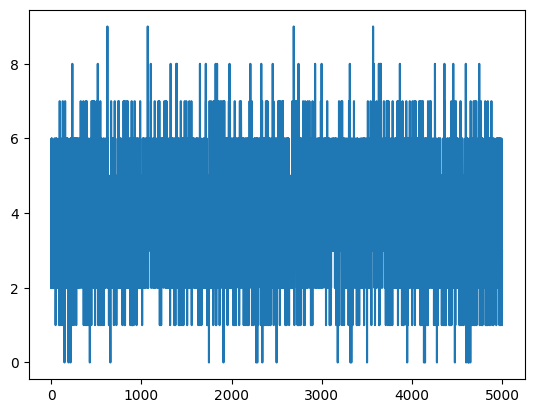

In [10]:
plt.plot(x_s)

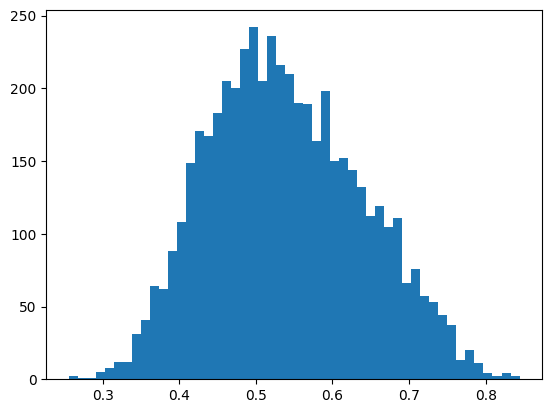

In [11]:
plt.hist(p_s,bins=50)
plt.show()

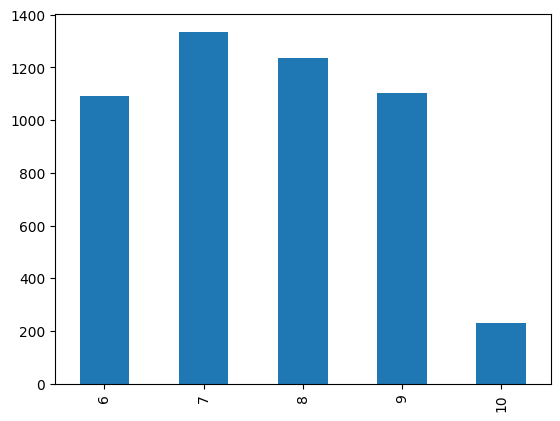

In [12]:
pd.Series(n_s).value_counts().sort_index().plot.bar()
plt.show()

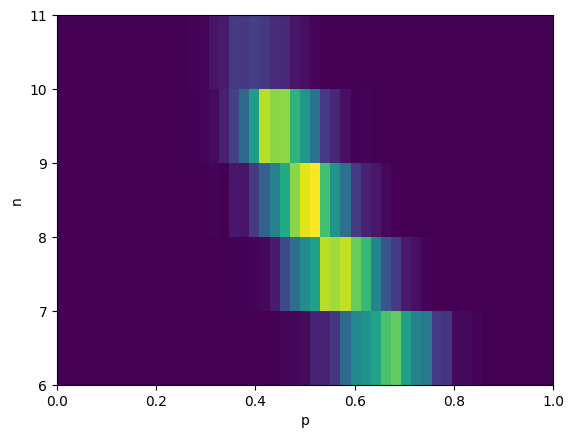

In [13]:
plt.hist2d(p_s,n_s, bins=[np.linspace(0,1,50), support_n+[11]])
plt.xlabel('p')
plt.ylabel('n')
plt.show()

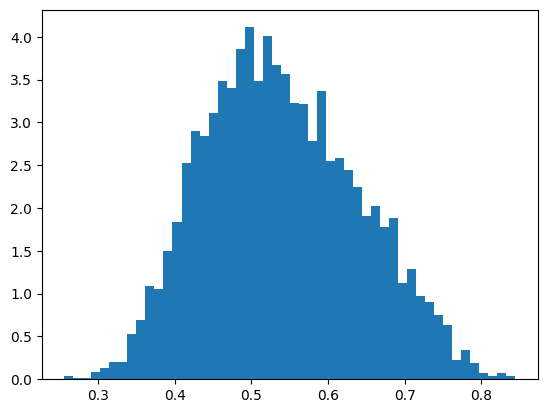

In [14]:
plt.hist(p_s,bins=50, density=True)
plt.show()

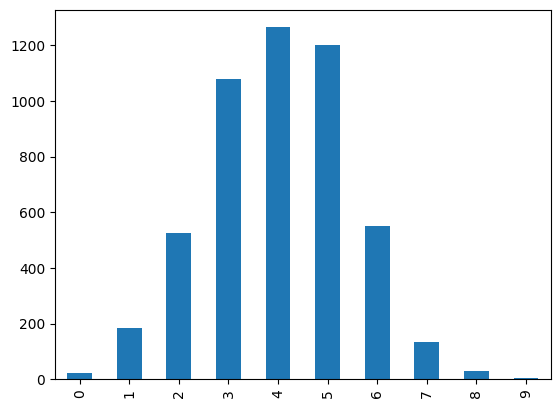

In [15]:
pd.Series(x_s).value_counts().sort_index().plot.bar()
plt.show()

Text(0.5, 1.0, 'x | n=8')

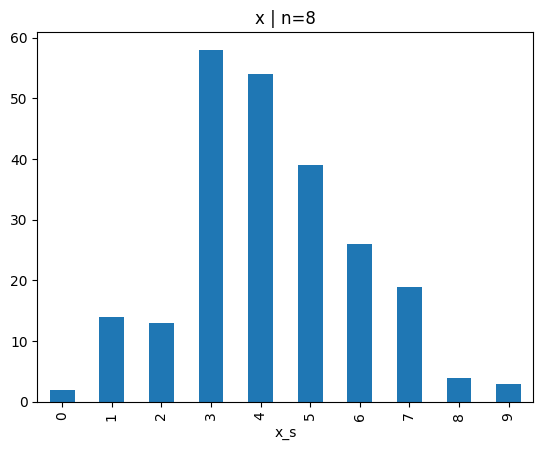

In [16]:
import pandas as pd

pd.DataFrame({'x_s': x_s, 'p_s': p_s, 'n_s': n_s}).query('n_s == 10').x_s.value_counts().sort_index().plot.bar()
plt.title('x | n=8')